In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [10]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


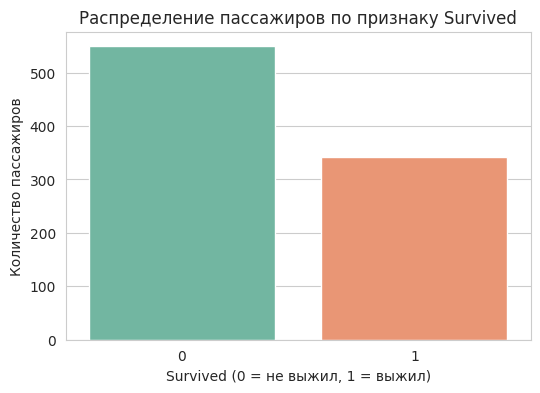

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Survived", hue="Survived", palette="Set2", legend=False)
plt.title("Распределение пассажиров по признаку Survived")
plt.xlabel("Survived (0 = не выжил, 1 = выжил)")
plt.ylabel("Количество пассажиров")
plt.show()

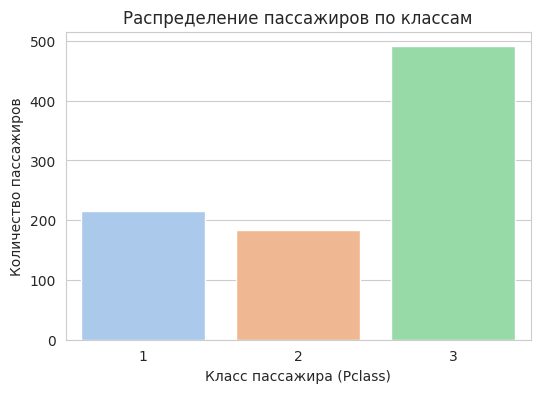

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Pclass", hue="Pclass", palette="pastel", legend=False)
plt.title("Распределение пассажиров по классам")
plt.xlabel("Класс пассажира (Pclass)")
plt.ylabel("Количество пассажиров")
plt.show()

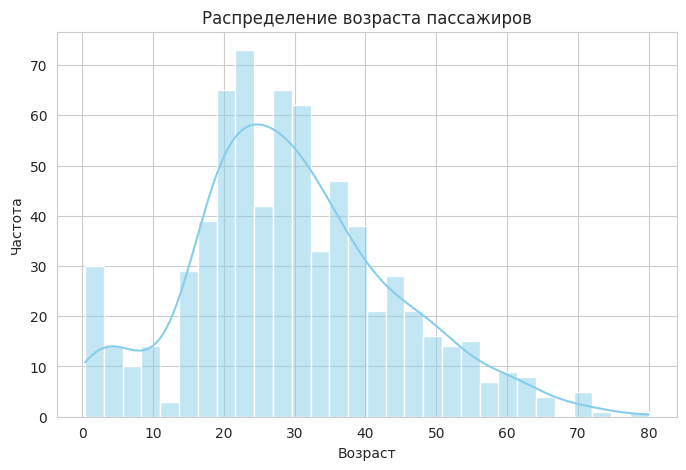

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"].dropna(), bins=30, kde=True, color="skyblue")
plt.title("Распределение возраста пассажиров")
plt.xlabel("Возраст")
plt.ylabel("Частота")
plt.show()

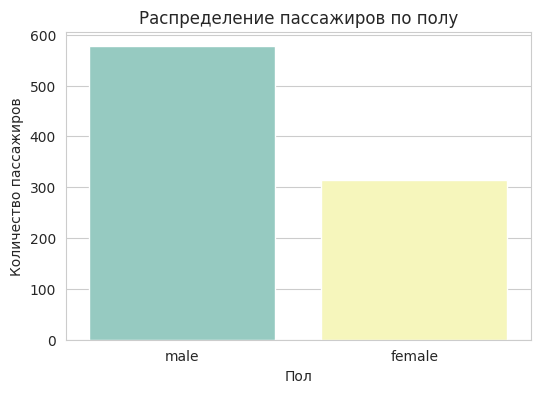

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sex", hue="Sex", palette="Set3", legend=False)
plt.title("Распределение пассажиров по полу")
plt.xlabel("Пол")
plt.ylabel("Количество пассажиров")
plt.show()

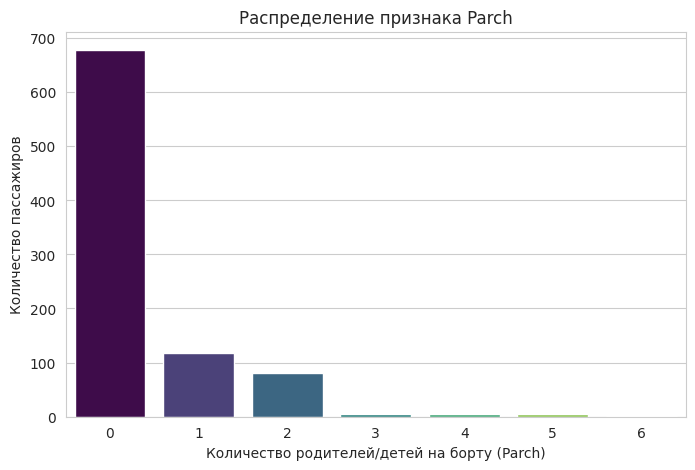

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Parch", hue="Parch", palette="viridis", legend=False)
plt.title("Распределение признака Parch")
plt.xlabel("Количество родителей/детей на борту (Parch)")
plt.ylabel("Количество пассажиров")
plt.show()

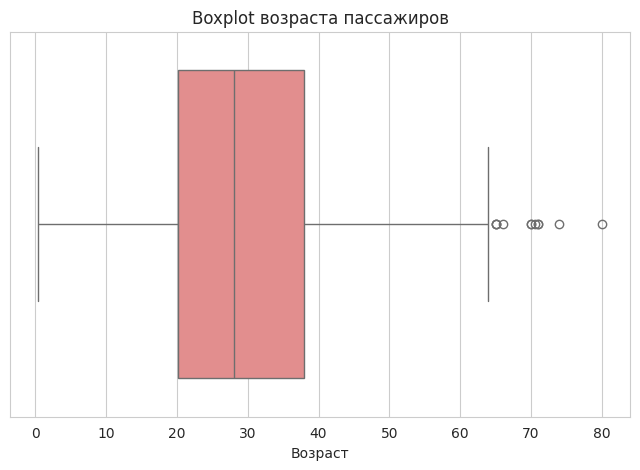

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Age"], color="lightcoral")
plt.title("Boxplot возраста пассажиров")
plt.xlabel("Возраст")
plt.show()

#Основная часть возрастов пассажиров сосредоточена в среднем диапазоне

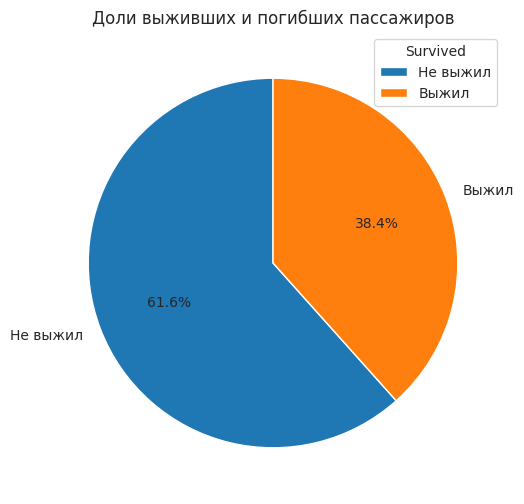

In [18]:
survived_counts = df["Survived"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    survived_counts,
    labels=["Не выжил", "Выжил"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Доли выживших и погибших пассажиров")
plt.legend(title="Survived")
plt.show()

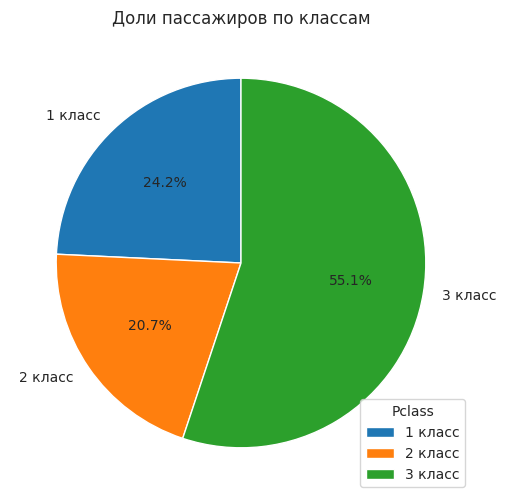

In [21]:
pclass_counts = df["Pclass"].value_counts().sort_index()

plt.figure(figsize=(6, 6))
plt.pie(
    pclass_counts,
    labels=[f"{i} класс" for i in pclass_counts.index],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Доли пассажиров по классам")
plt.legend(title="Pclass")
plt.show()

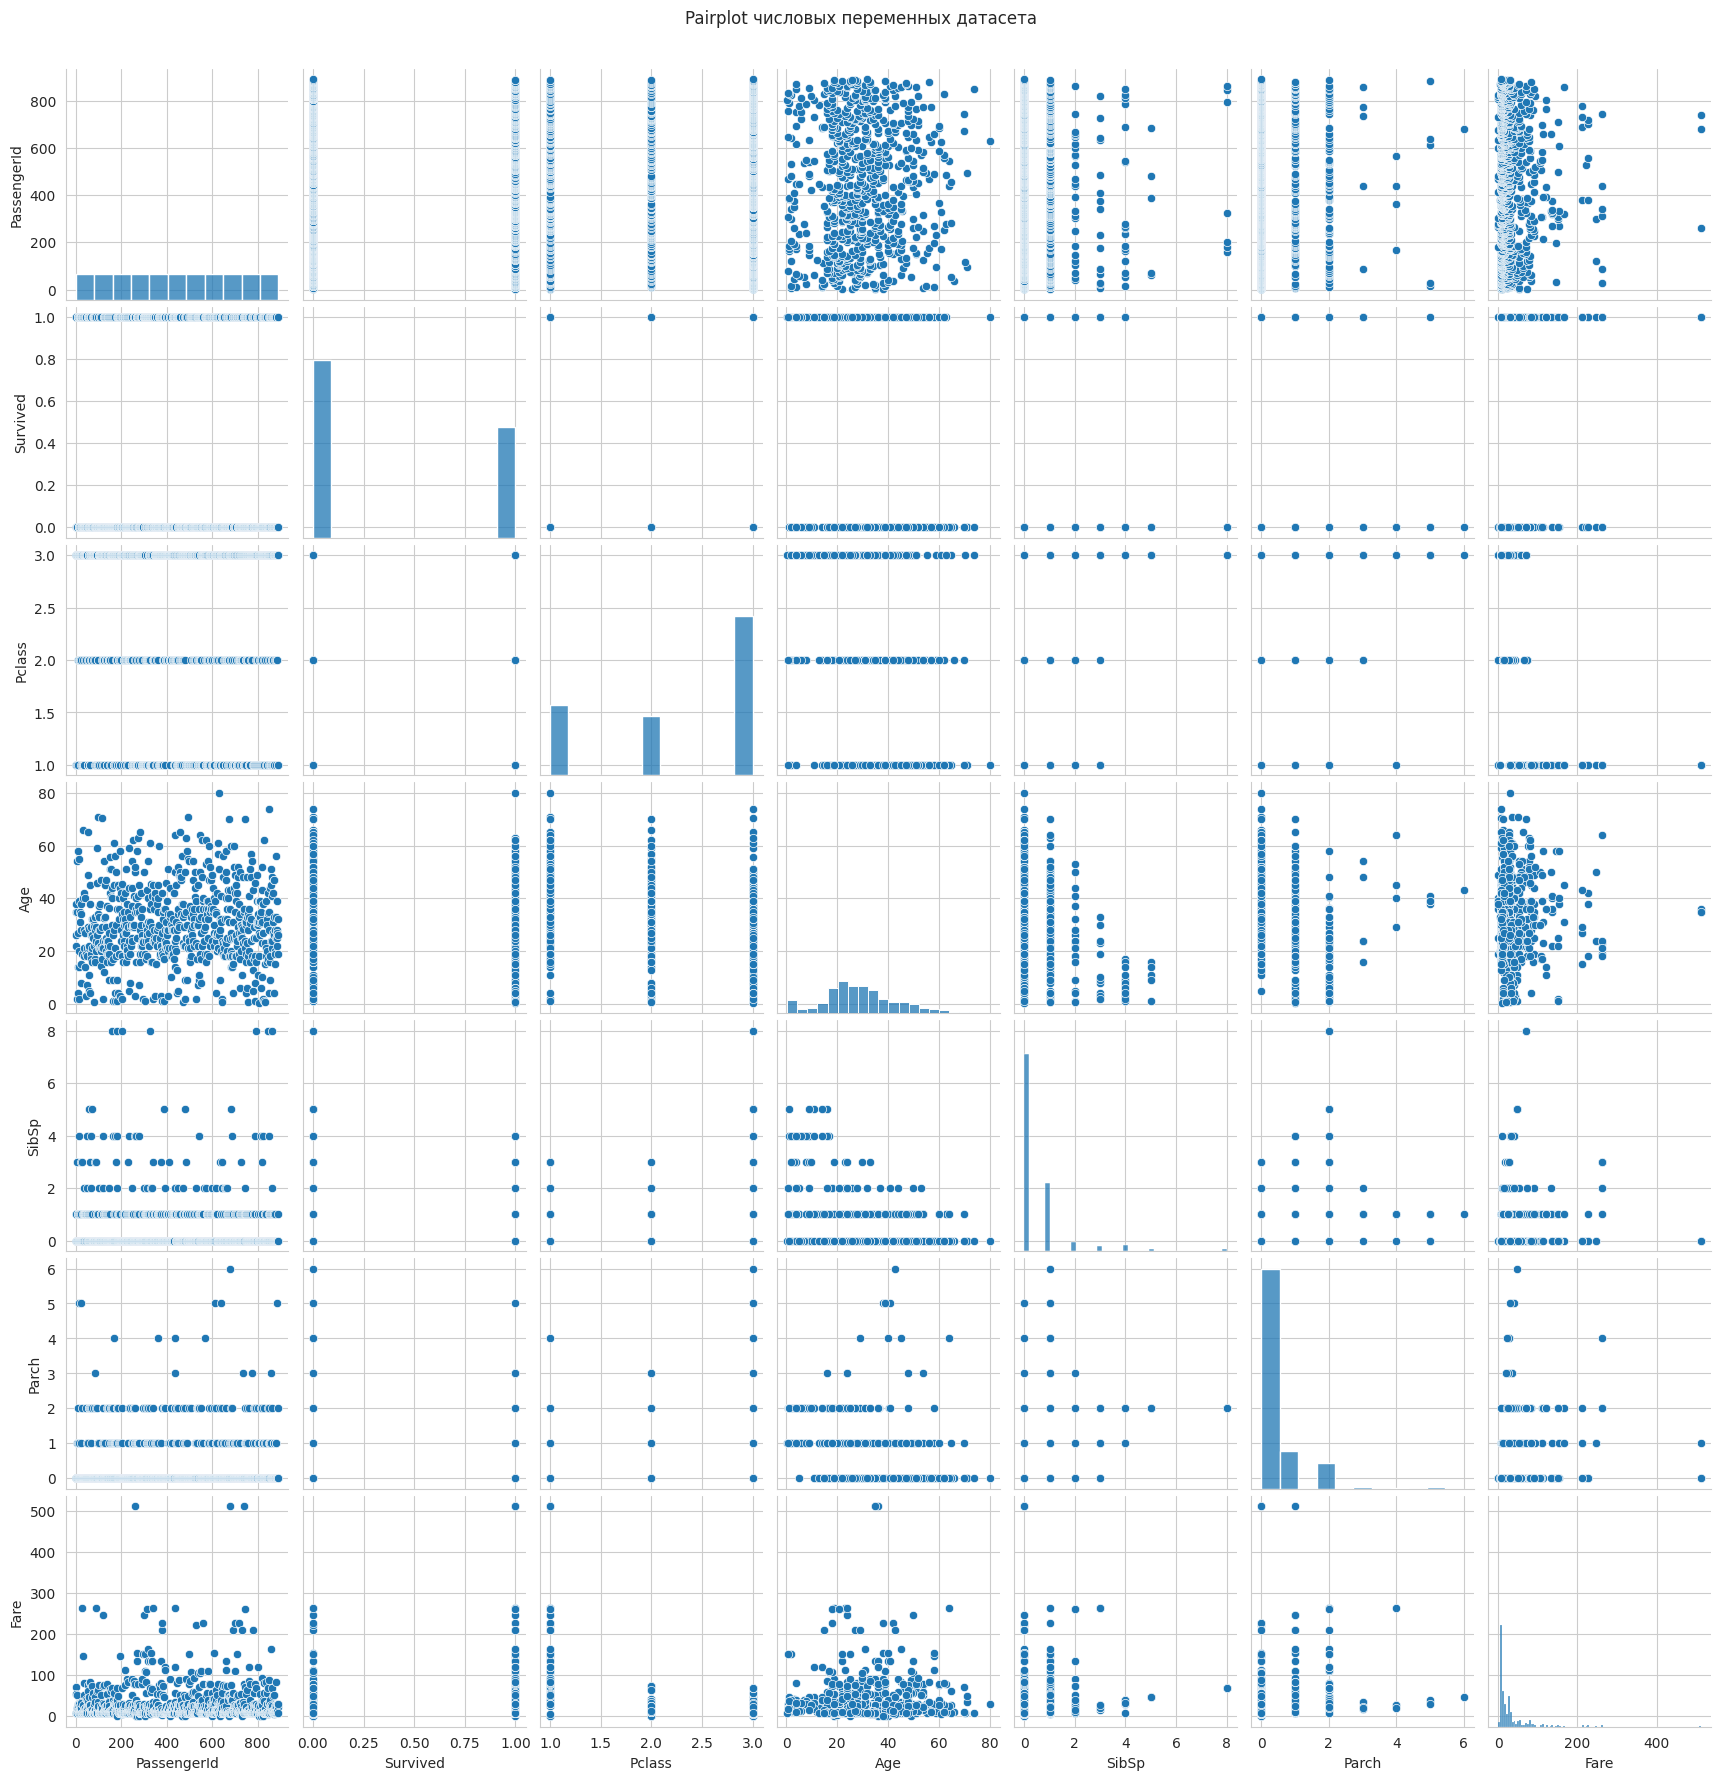

In [23]:
numeric_df = df.select_dtypes(include=["number"])
sns.pairplot(numeric_df)
plt.suptitle("Pairplot числовых переменных датасета", y=1.02)
plt.show()

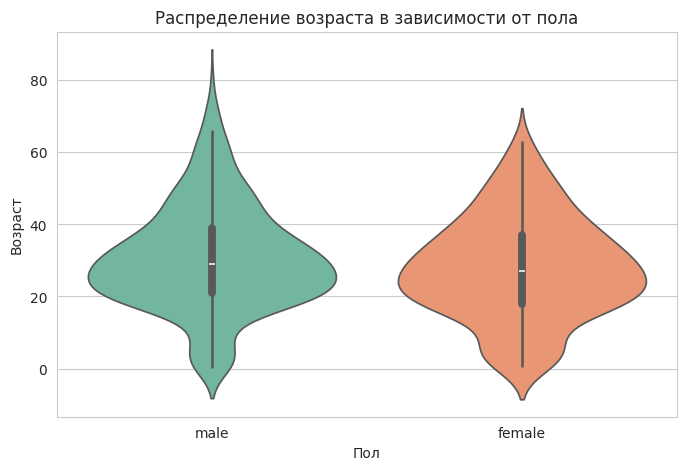

In [24]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="Sex", y="Age", hue="Sex", palette="Set2", legend=False)
plt.title("Распределение возраста в зависимости от пола")
plt.xlabel("Пол")
plt.ylabel("Возраст")
plt.show()

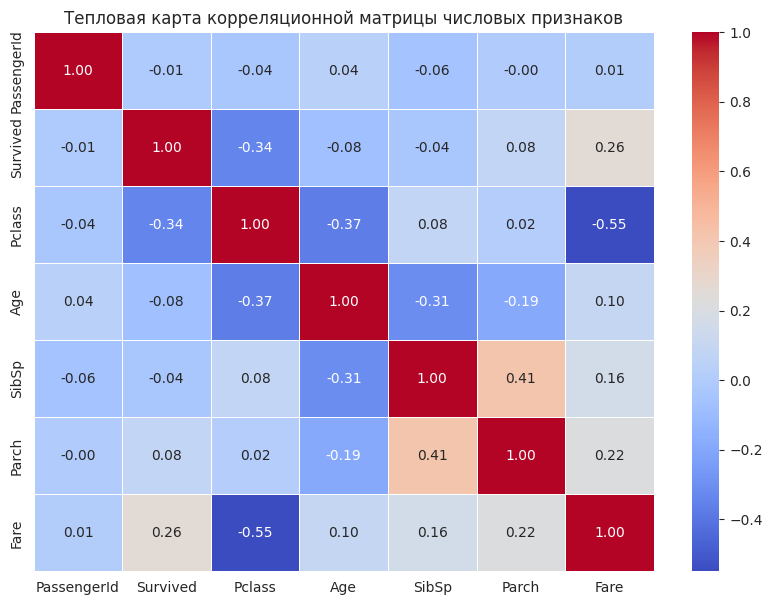

In [25]:
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Тепловая карта корреляционной матрицы числовых признаков")
plt.show()

In [26]:
sunburst_data = (
    df.groupby(["Pclass", "Sex"])
    .size()
    .reset_index(name="Count")
)

sunburst_data

,Pclass,Sex,Count
0,1,female,94
1,1,male,122
2,2,female,76
3,2,male,108
4,3,female,144
5,3,male,347


In [27]:
fig = px.sunburst(
    sunburst_data,
    path=["Pclass", "Sex"],
    values="Count",
    title="Sunburst plot: количество пассажиров по классам и полу"
)

fig.show()